# Raw IQ trials: object localization and phase motion

This notebook loads CSV files produced by `get_iq_main.py` that follow the schema in
`benchmarking/guides/RAW_IQ_CSV_SCHEMA.md`.

**Dependencies:** `pandas`, `numpy`, `matplotlib`, `seaborn`.

**Firmware context:** Each row is one range bin from a cached IQ frame on the XM125 (`fid` =
firmware frame id). Compare **trials** and use phase / amplitude to reason about object range and
sub-millimeter motion (phase-to-mm requires calibration — see `MM_PER_RAD` below).

**Run location:** Prefer launching Jupyter with **working directory = repo root** (`xm125/`), or set `CSV_PATH` to an absolute path.

**Strength outliers:** Set `MAX_STRENGTH` in the config cell to cap `amplitude` before heatmaps / bump detection (raw magnitude is kept in `amplitude_raw`).

**Bin mask:** Set `EXCLUDE_BIN_RANGE = (lo, hi)` to drop all rows with `lo <= bin_index <= hi` (inclusive), e.g. `(1, 10)` removes bins 1 through 10.

**Bin ruler (§2c):** Set `BIN_SIZE_MM` to map fractional `local_centroid_bin` from bump detection to an estimated range in mm.


In [ ]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    from scipy.signal import find_peaks
except ImportError:
    find_peaks = None

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)

# --- Configuration (edit these) ---
# Repo root: cwd if it contains benchmarking/, else parent (when cwd is data_vis/)
_cwd = Path.cwd()
if (_cwd / "benchmarking").is_dir():
    REPO_ROOT = _cwd
elif (_cwd.parent / "benchmarking").is_dir():
    REPO_ROOT = _cwd.parent
else:
    REPO_ROOT = _cwd

CSV_PATH = REPO_ROOT / "benchmarking" / "data" / "iqfc_static_test_3.csv"  # TODO: set your file

SENSOR_FILTER: str | None = None  # e.g. "BACK" or None for all
TRIALS_OF_INTEREST: list[int] | None = None  # e.g. [0, 1] or None for all trials
STRICT_METADATA = True  # drop rows missing host_frame_id / firmware_frame_id for analysis

# Strength profile per trial: aggregate all frames in a trial, then detect "bumps" (peaks)
STRENGTH_AGG = "mean"  # "mean" or "median" across frames within each trial
PEAK_PROMINENCE_REL = 0.08  # prominence >= PEAK_PROMINENCE_REL * max(profile); tune per dataset
PEAK_DISTANCE_BINS = 5  # minimum bin separation between detected bumps
BUMP_LOCAL_HALF_WIDTH = 4  # bins each side of peak for local centroid + candidate pooling

# Outlier trim for strength aggregations (heatmap, bump detection, centroid). None = no cap.
MAX_STRENGTH: float | None = None  # e.g. 1e5; clip amplitude to this max before aggregating

# Drop rows whose bin_index falls in this inclusive range, e.g. (1, 10) removes bins 1..10. None = keep all.
EXCLUDE_BIN_RANGE: tuple[int, int] | None = (0,6)

# Crude range-from-bin ruler (§2c): estimated_range_mm ≈ local_centroid_bin * BIN_SIZE_MM
BIN_SIZE_MM = 5.0  # assumed mm per bin index unit; set to match your radar / export

# Phase pooling + optional mm scale (physical model / calibration — None = phase only)
MM_PER_RAD: float | None = None  # e.g. wavelength / (4*pi) style factor if known; else leave None
SUB_MM_THRESHOLD = 0.005  # 5 mm — only used when MM_PER_RAD is set

# §4b scatter (bin × strength, every row): False = phase as color (`twilight`); True = phase as marker area (often clearer when dense/overlapping).
PHASE_AS_MARKER_SIZE: bool = True

print("REPO_ROOT:", REPO_ROOT.resolve())
print("CSV_PATH:", CSV_PATH.resolve())
if find_peaks is None:
    print("Note: scipy not installed — using simple peak picker (install scipy for better bump detection).")


REPO_ROOT: C:\Users\caden\vieregg-lab\xm125
CSV_PATH: C:\Users\caden\vieregg-lab\xm125\benchmarking\data\iqfc_static_test_3.csv


## 1. Schema columns and load


In [79]:
SCHEMA_COLUMNS = [
    "trial",
    "host_frame_id",
    "sensor",
    "i2c_addr_hex",
    "bins",
    "firmware_frame_id",
    "t_ms",
    "bin_index",
    "I",
    "Q",
    "expected_distance_mm",
]

df_raw = pd.read_csv(CSV_PATH)
missing = [c for c in SCHEMA_COLUMNS if c not in df_raw.columns]
if missing:
    raise ValueError(f"CSV missing schema columns: {missing}")

print(f"Loaded {len(df_raw):,} rows, {df_raw['trial'].nunique()} trials")
print(df_raw.head(3))


Loaded 1,272 rows, 12 trials
   trial  host_frame_id sensor i2c_addr_hex  bins  firmware_frame_id     t_ms  \
0      0             50   BACK         0x52    53                 51  4645710   
1      0             50   BACK         0x52    53                 51  4645710   
2      0             50   BACK         0x52    53                 51  4645710   

   bin_index            I            Q  expected_distance_mm  
0          0  5735.399902 -2188.100098                   NaN  
1          1     0.000000    47.299999                   NaN  
2          2     0.000000    40.200001                   NaN  


## 2. Clean and type coercion


In [80]:
def to_num(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s, errors="coerce")


df = df_raw.copy()
for col in ("trial", "bin_index", "bins", "host_frame_id", "firmware_frame_id", "t_ms", "I", "Q"):
    df[col] = to_num(df[col])

# expected_distance_mm may be empty strings
df["expected_distance_mm"] = to_num(df["expected_distance_mm"])

# Drop non-finite IQ
mask_iq = np.isfinite(df["I"]) & np.isfinite(df["Q"])
dropped_iq = (~mask_iq).sum()
df = df.loc[mask_iq].copy()

if SENSOR_FILTER:
    df = df.loc[df["sensor"].astype(str) == SENSOR_FILTER].copy()

if TRIALS_OF_INTEREST is not None:
    df = df.loc[df["trial"].isin(TRIALS_OF_INTEREST)].copy()

if STRICT_METADATA:
    m = df["host_frame_id"].notna() & df["firmware_frame_id"].notna()
    dropped_meta = int((~m).sum())
    df = df.loc[m].copy()
else:
    dropped_meta = 0

# Frame key (per RAW_IQ_CSV_SCHEMA)
df["frame_key"] = (
    df["trial"].astype(int).astype(str)
    + "_"
    + df["host_frame_id"].astype(int).astype(str)
    + "_"
    + df["sensor"].astype(str)
    + "_"
    + df["firmware_frame_id"].astype(int).astype(str)
)

# Dedupe accidental duplicate (frame_key, bin_index)
dupes = df.duplicated(subset=["frame_key", "bin_index"], keep=False).sum()
df = df.drop_duplicates(subset=["frame_key", "bin_index"], keep="first")

# Exclude bins in inclusive [lo, hi] from all downstream analysis
if EXCLUDE_BIN_RANGE is not None:
    lo, hi = int(EXCLUDE_BIN_RANGE[0]), int(EXCLUDE_BIN_RANGE[1])
    if lo > hi:
        lo, hi = hi, lo
    _n_before = len(df)
    _mask_ex = (df["bin_index"] >= lo) & (df["bin_index"] <= hi)
    df = df.loc[~_mask_ex].copy()
    print(
        f"EXCLUDE_BIN_RANGE inclusive ({lo}, {hi}): removed {int(_mask_ex.sum())} rows "
        f"({_n_before} -> {len(df)})"
    )

# Order: trial, then file order preserved — add monotonic frame sequence per trial for plotting
df["_row_order"] = np.arange(len(df))
df["frame_seq"] = df.groupby("trial")["host_frame_id"].transform(
    lambda s: pd.factorize(s, sort=False)[0]
)

# Derived physics columns
df["amplitude_raw"] = np.sqrt(df["I"] ** 2 + df["Q"] ** 2)
df["amplitude"] = df["amplitude_raw"]
if MAX_STRENGTH is not None:
    cap = float(MAX_STRENGTH)
    n_clip = int((df["amplitude"] > cap).sum())
    df["amplitude"] = np.minimum(df["amplitude"], cap)
    print(f"MAX_STRENGTH={cap}: clipped {n_clip} rows (amplitude capped for aggregations; I/Q unchanged)")
df["phase_rad"] = np.arctan2(df["Q"], df["I"])

print("Dropped non-finite I/Q rows:", int(dropped_iq))
if STRICT_METADATA:
    print("Dropped missing metadata rows:", dropped_meta)
else:
    print("STRICT_METADATA=False: kept rows with missing frame metadata")
print("Potential duplicate groups (before drop):", int(dupes) > 0)
print("Rows after clean:", len(df))


EXCLUDE_BIN_RANGE inclusive (0, 6): removed 168 rows (1272 -> 1104)
Dropped non-finite I/Q rows: 0
Dropped missing metadata rows: 0
Potential duplicate groups (before drop): False
Rows after clean: 1104


## 2b. Bump detection helpers

Strength is aggregated **within each trial** (all frames). **Bumps** = `scipy.signal.find_peaks` on `amplitude` vs `bin_index` (prominence + minimum separation). Each bump gets a **local centroid** over `BUMP_LOCAL_HALF_WIDTH` bins around the peak. If SciPy is missing, a simple greedy local-maximum picker is used.

In [81]:
def trial_sensor_profile(sub: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    """Sorted bin_index and aggregated strength (mean/median across frames in this trial)."""
    agg = sub.groupby("bin_index", observed=True)["amplitude"].agg(STRENGTH_AGG)
    agg = agg.sort_index()
    b = agg.index.astype(float).values
    w = agg.values.astype(float)
    return b, w


def find_peaks_simple(w: np.ndarray, min_height: float, min_dist: int) -> np.ndarray:
    """Greedy local-maxima when scipy is unavailable."""
    w = np.asarray(w, float)
    n = len(w)
    if n < 3:
        return np.array([], dtype=int)
    local_max = np.zeros(n, dtype=bool)
    local_max[1:-1] = (w[1:-1] >= w[:-2]) & (w[1:-1] > w[2:])
    cand = np.where(local_max & (w >= min_height))[0]
    order = cand[np.argsort(-w[cand])]
    kept: list[int] = []
    for i in order:
        if all(abs(int(i) - j) >= min_dist for j in kept):
            kept.append(int(i))
    return np.array(sorted(kept), dtype=int)


def detect_strength_bumps(b: np.ndarray, w: np.ndarray) -> pd.DataFrame:
    """Return one row per detected bump (object-like return in range)."""
    cols = ["peak_bin", "local_centroid_bin", "prominence", "peak_height"]
    if len(w) == 0 or np.nanmax(w) <= 0:
        return pd.DataFrame(columns=cols)
    wmax = float(np.nanmax(w))
    prom_min = PEAK_PROMINENCE_REL * wmax + 1e-12
    dist = max(1, int(PEAK_DISTANCE_BINS))
    if find_peaks is not None:
        peaks, props = find_peaks(w, prominence=prom_min, distance=dist)
        prominences = props.get("prominences", np.zeros(len(peaks), dtype=float))
    else:
        peaks = find_peaks_simple(w, min_height=prom_min, min_dist=dist)
        prominences = np.zeros(len(peaks), dtype=float)
    rows = []
    hw = int(BUMP_LOCAL_HALF_WIDTH)
    for pi, pk in enumerate(peaks):
        lo = max(0, int(pk) - hw)
        hi = min(len(b) - 1, int(pk) + hw)
        bw = b[lo : hi + 1]
        ww = w[lo : hi + 1]
        if ww.sum() <= 0:
            cent = float(b[int(pk)])
        else:
            cent = float(np.sum(bw * ww) / np.sum(ww))
        prom = float(prominences[pi]) if len(prominences) > pi else float("nan")
        rows.append(
            {
                "peak_bin": float(b[int(pk)]),
                "local_centroid_bin": cent,
                "prominence": prom,
                "peak_height": float(w[int(pk)]),
            }
        )
    return pd.DataFrame(rows)


def candidate_bins_from_bumps(bump_df: pd.DataFrame, b: np.ndarray) -> list[float]:
    """Union of bins near each bump local centroid."""
    if bump_df is None or bump_df.empty:
        return []
    out: set[float] = set()
    hw = float(BUMP_LOCAL_HALF_WIDTH)
    for _, r in bump_df.iterrows():
        c = float(r["local_centroid_bin"])
        for bi in b:
            if abs(float(bi) - c) <= hw:
                out.add(float(bi))
    return sorted(out)


# Build bump table for all (trial, sensor)
_bump_rows: list[dict] = []
for (trial, sensor), sub in df.groupby(["trial", "sensor"]):
    b, w = trial_sensor_profile(sub)
    bumps = detect_strength_bumps(b, w)
    for i, (_, br) in enumerate(bumps.iterrows()):
        _bump_rows.append(
            {
                "trial": int(trial),
                "sensor": str(sensor),
                "bump_id": int(i),
                "peak_bin": br["peak_bin"],
                "local_centroid_bin": br["local_centroid_bin"],
                "prominence": br["prominence"],
                "peak_height": br["peak_height"],
            }
        )
bump_tbl = pd.DataFrame(_bump_rows)
print("Detected bumps (rows):", len(bump_tbl))
if len(bump_tbl):
    print(bump_tbl.head(12).to_string(index=False))

Detected bumps (rows): 12
 trial sensor  bump_id  peak_bin  local_centroid_bin  prominence  peak_height
     0   BACK        0      41.0           41.051458  528.797919   933.346202
     1   BACK        0      38.0           38.033655  630.016571   816.608781
     2   BACK        0      41.0           41.044043  353.734951   595.053530
     3   BACK        0      41.0           40.875088  668.528579  1011.629244
     4   BACK        0      38.0           37.950228  536.214081   555.415544
     5   BACK        0      41.0           40.979060  551.825946   841.120071
     6   BACK        0      39.0           38.920623  562.561160   740.945196
     7   BACK        0      41.0           40.922273  422.578460   574.474993
     8   BACK        0      39.0           39.063877  587.224377   848.803261
     9   BACK        0      39.0           38.985192  397.858358   471.565456
    10   BACK        0      39.0           39.111740  605.222684   785.513302
    11   BACK        0      39.0      

## 2c. Crude range from bump centroid (linear bin ruler)

Uses **`local_centroid_bin`** from §2b (fractional, not quantized) and **`BIN_SIZE_MM`** from the config cell:

`estimated_range_mm ≈ local_centroid_bin × BIN_SIZE_MM`

This is only as accurate as your bin spacing model. When several bumps exist in one trial, we take the **strongest** bump (`peak_height`) for the line plot; all bumps are shown in a scatter as well.

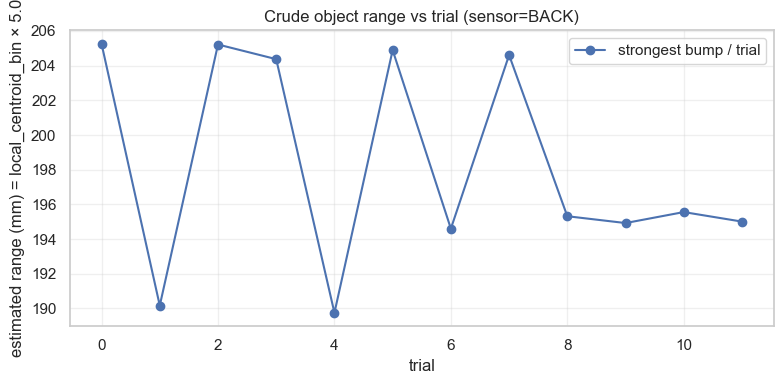

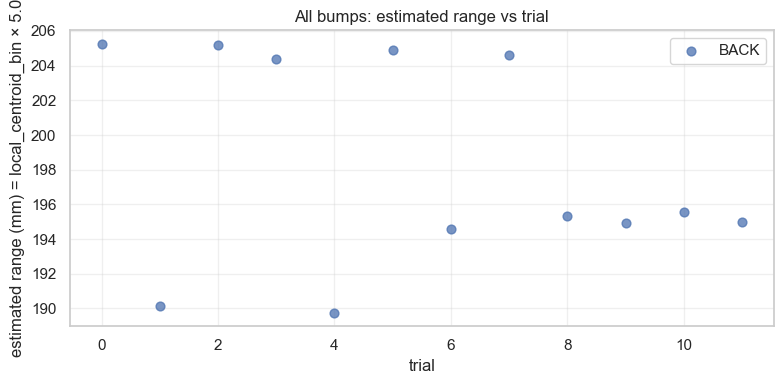

 trial sensor  bump_id  local_centroid_bin  distance_est_mm  peak_height
     0   BACK        0           41.051458       205.257292   933.346202
     1   BACK        0           38.033655       190.168273   816.608781
     2   BACK        0           41.044043       205.220214   595.053530
     3   BACK        0           40.875088       204.375439  1011.629244
     4   BACK        0           37.950228       189.751142   555.415544
     5   BACK        0           40.979060       204.895300   841.120071
     6   BACK        0           38.920623       194.603114   740.945196
     7   BACK        0           40.922273       204.611367   574.474993
     8   BACK        0           39.063877       195.319387   848.803261
     9   BACK        0           38.985192       194.925961   471.565456
    10   BACK        0           39.111740       195.558701   785.513302
    11   BACK        0           39.001920       195.009601   618.104041


In [82]:
if len(bump_tbl) == 0:
    print("No bumps in bump_tbl — run §2b after collecting data.")
else:
    # Strongest bump per (trial, sensor) for a single range estimate vs trial
    _idx = bump_tbl.groupby(["trial", "sensor"], observed=True)["peak_height"].idxmax()
    bump_primary = bump_tbl.loc[_idx].copy()
    bump_primary["distance_est_mm"] = bump_primary["local_centroid_bin"].astype(float) * float(BIN_SIZE_MM)

    for sensor in sorted(bump_primary["sensor"].unique()):
        g = bump_primary[bump_primary["sensor"] == sensor].sort_values("trial")
        plt.figure(figsize=(8, 4))
        plt.plot(g["trial"], g["distance_est_mm"], "o-", lw=1.5, label="strongest bump / trial")
        plt.xlabel("trial")
        plt.ylabel(f"estimated range (mm) = local_centroid_bin × {BIN_SIZE_MM}")
        plt.title(f"Crude object range vs trial (sensor={sensor})")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

    # All detected bumps (multiple per trial possible)
    bt2 = bump_tbl.copy()
    bt2["distance_est_mm"] = bt2["local_centroid_bin"].astype(float) * float(BIN_SIZE_MM)
    plt.figure(figsize=(8, 4))
    for sensor in sorted(bt2["sensor"].unique()):
        gs = bt2[bt2["sensor"] == sensor]
        plt.scatter(gs["trial"], gs["distance_est_mm"], s=40, alpha=0.75, label=str(sensor))
    plt.xlabel("trial")
    plt.ylabel(f"estimated range (mm) = local_centroid_bin × {BIN_SIZE_MM}")
    plt.title("All bumps: estimated range vs trial")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    display_cols = ["trial", "sensor", "bump_id", "local_centroid_bin", "distance_est_mm", "peak_height"]
    print(bump_primary[display_cols].sort_values(["sensor", "trial"]).to_string(index=False))

## 3. Summary statistics


Frames per trial/sensor:
 trial sensor  n_frames
     0   BACK         2
     1   BACK         2
     2   BACK         2
     3   BACK         2
     4   BACK         2
     5   BACK         2
     6   BACK         2
     7   BACK         2
     8   BACK         2
     9   BACK         2
    10   BACK         2
    11   BACK         2

Amplitude by trial (overall):
       count        mean         std      median
trial                                           
0         92  332.070110  352.631830  159.000000
1         92  287.203407  299.680395  210.679750
2         92  205.055297  224.752285   54.599034
3         92  376.479150  384.738617  285.752801
4         92  180.864443  205.415057   60.201073
5         92  292.438397  310.726744  159.400002
6         92  280.456750  278.568077  212.637589
7         92  185.082346  208.049685   41.949998
8         92  324.553981  317.288206  269.012237
9         92  171.059925  172.380195  119.465819
10        92  271.753914  288.685557  168.53

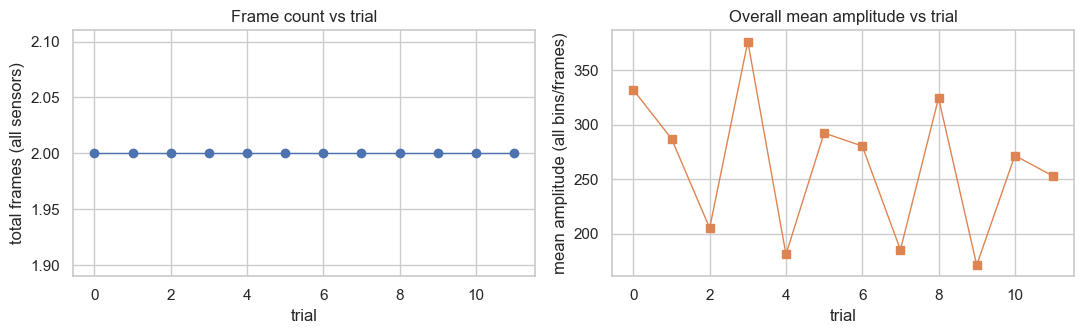

In [83]:
def circular_mean_resultant(angles: np.ndarray) -> tuple[float, float]:
    """Return (mean_angle, R) where R = |E[exp(i phi)]| in [0,1]."""
    z = np.exp(1j * np.asarray(angles, dtype=float))
    m = z.mean()
    return float(np.angle(m)), float(np.abs(m))


summary_frames = (
    df.groupby(["trial", "sensor"], dropna=False)["frame_key"]
    .nunique()
    .rename("n_frames")
    .reset_index()
)
bins_per = df.groupby(["trial", "sensor", "frame_key"])["bin_index"].nunique().rename("bins_in_frame")
print("Frames per trial/sensor:")
print(summary_frames.to_string(index=False))

print("\nAmplitude by trial (overall):")
print(df.groupby("trial")["amplitude"].agg(["count", "mean", "std", "median"]).round(6).to_string())

# Phase stability: per (trial, sensor, bin_index) across frames
stab = (
    df.groupby(["trial", "sensor", "bin_index"], observed=True)["phase_rad"]
    .apply(lambda s: circular_mean_resultant(s.values)[1])
    .rename("phase_resultant_R")
    .reset_index()
)
print("\nPhase stability (R=1 means identical phase across frames in that bin). Summary of R:")
print(stab["phase_resultant_R"].describe().round(4).to_string())

exp_tbl = df.drop_duplicates("trial")[["trial", "expected_distance_mm"]]
if exp_tbl["expected_distance_mm"].notna().any():
    print("\nExpected distance (mm) by trial:")
    print(exp_tbl.to_string(index=False))
else:
    print("\nNo expected_distance_mm values in CSV.")

# --- Plots vs trial (primary x-axis for summary trends) ---
_trials = sorted(df["trial"].unique().astype(int))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
ax0, ax1 = axes
ax0.plot(_trials, summary_frames.groupby("trial")["n_frames"].sum().reindex(_trials).values, "o-", lw=1)
ax0.set_xlabel("trial")
ax0.set_ylabel("total frames (all sensors)")
ax0.set_title("Frame count vs trial")

amp_by_trial = df.groupby("trial", observed=True)["amplitude"].mean().reindex(_trials)
ax1.plot(_trials, amp_by_trial.values, "s-", color="C1", lw=1)
ax1.set_xlabel("trial")
ax1.set_ylabel("mean amplitude (all bins/frames)")
ax1.set_title("Overall mean amplitude vs trial")
plt.tight_layout()
plt.show()


## 4. Exploratory plots (change over **trial**)

**Heatmap:** mean amplitude aggregated across all frames in each trial — **x = trial**, **y = bin_index** (how the range profile shifts across trials).

**Markers:** primary strength bump’s local centroid bin vs trial (from bump detection in §6).


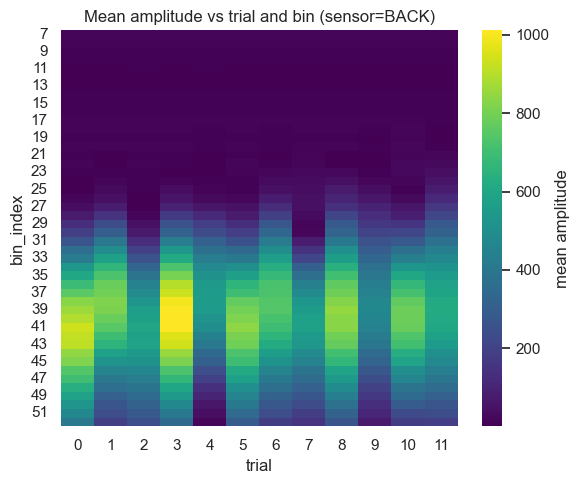

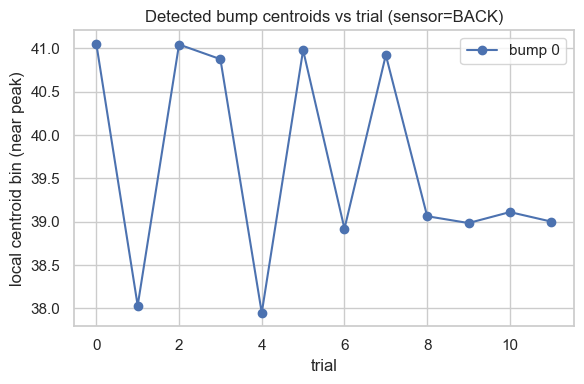

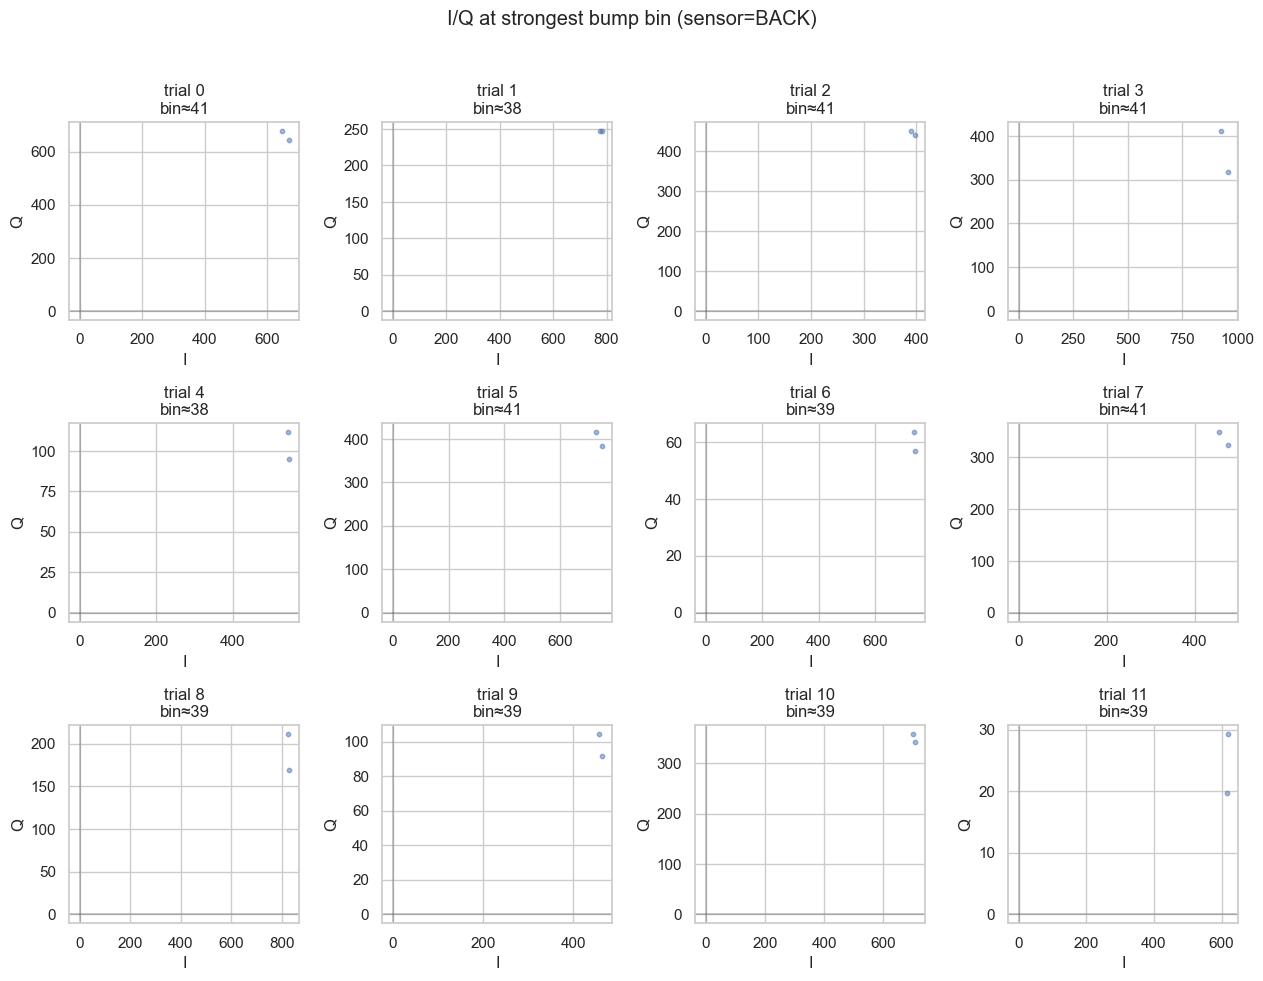

In [84]:
# Mean amplitude: trial × bin_index (x = trial), one heatmap per sensor
for sensor in sorted(df["sensor"].unique()):
    sub = df[df["sensor"] == sensor]
    heat = (
        sub.groupby(["trial", "bin_index"], observed=True)["amplitude"]
        .mean()
        .reset_index()
        .pivot(index="bin_index", columns="trial", values="amplitude")
        .sort_index()
    )
    trials_sorted = sorted(heat.columns.astype(int))
    heat = heat[trials_sorted]
    plt.figure(figsize=(max(6, len(trials_sorted) * 0.35), 5))
    sns.heatmap(heat, cmap="viridis", cbar_kws={"label": "mean amplitude"})
    plt.title(f"Mean amplitude vs trial and bin (sensor={sensor})")
    plt.xlabel("trial")
    plt.ylabel("bin_index")
    plt.tight_layout()
    plt.show()

# Primary bump local centroid vs trial (bump_id == 0: strongest bump per trial if sorted by height)
# Plot each bump_id as its own line when multiple objects per trial
for sensor in sorted(df["sensor"].unique()):
    bt = bump_tbl[bump_tbl["sensor"] == sensor]
    if bt.empty:
        continue
    plt.figure(figsize=(max(6, bt["trial"].nunique() * 0.35), 4))
    for bid, g in bt.groupby("bump_id"):
        gg = g.sort_values("trial")
        plt.plot(gg["trial"], gg["local_centroid_bin"], "o-", label=f"bump {int(bid)}")
    plt.xlabel("trial")
    plt.ylabel("local centroid bin (near peak)")
    plt.title(f"Detected bump centroids vs trial (sensor={sensor})")
    plt.legend()
    plt.tight_layout()
    plt.show()

# IQ scatter: one panel per trial (small multiples), dominant bump bin for that trial
_trials_u = sorted(df["trial"].unique().astype(int))
_sensor0 = sorted(df["sensor"].unique())[0]
nc = min(4, len(_trials_u))
nr = int(np.ceil(len(_trials_u) / nc))
fig, axes = plt.subplots(nr, nc, figsize=(3.2 * nc, 3.2 * nr), squeeze=False)
for ax, trial in zip(axes.ravel(), _trials_u):
    sub_t = df[(df["trial"] == trial) & (df["sensor"] == _sensor0)]
    b, w = trial_sensor_profile(sub_t)
    bumps = detect_strength_bumps(b, w)
    if bumps.empty:
        dom_bin = float(sub_t.groupby("bin_index")["amplitude"].mean().idxmax())
    else:
        j = int(bumps["peak_height"].values.argmax())
        dom_bin = float(bumps.iloc[j]["peak_bin"])
    ss = df[(df["trial"] == trial) & (df["bin_index"] == dom_bin)]
    ax.scatter(ss["I"], ss["Q"], s=10, alpha=0.5)
    ax.axhline(0, color="k", lw=0.3)
    ax.axvline(0, color="k", lw=0.3)
    ax.set_title(f"trial {trial}\nbin≈{dom_bin:.0f}")
    ax.set_xlabel("I")
    ax.set_ylabel("Q")
for j in range(len(_trials_u), nr * nc):
    axes.ravel()[j].set_visible(False)
plt.suptitle(f"I/Q at strongest bump bin (sensor={_sensor0})", y=1.02)
plt.tight_layout()
plt.show()


## 4b. Every row: bin × strength, phase visual (**per trial**)

For each **sensor** and each **trial**, scatter **every IQ row** in that slice: **x = `bin_index`**, **y = `amplitude`** (strength after `MAX_STRENGTH` if set). Phase is shown either as **color** on the cyclic **`twilight`** map (\([-\pi, \pi]\)), or as **marker size** when `PHASE_AS_MARKER_SIZE` is True in the config cell (small ≈ \(-\pi\), large ≈ \(+\pi\); fixed blue markers for easier reading when many points overlap). Overlapping points are the same bin across different frames.

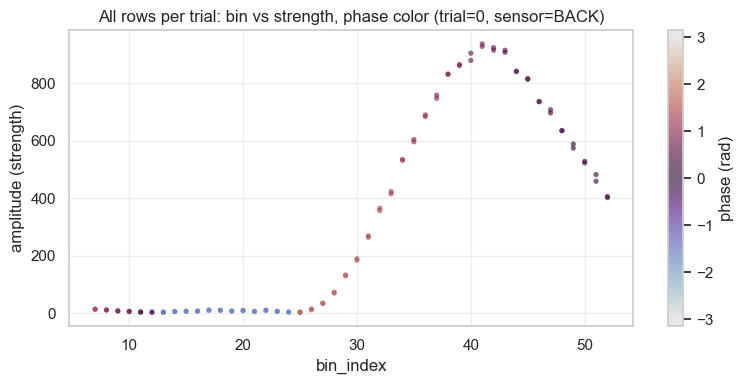

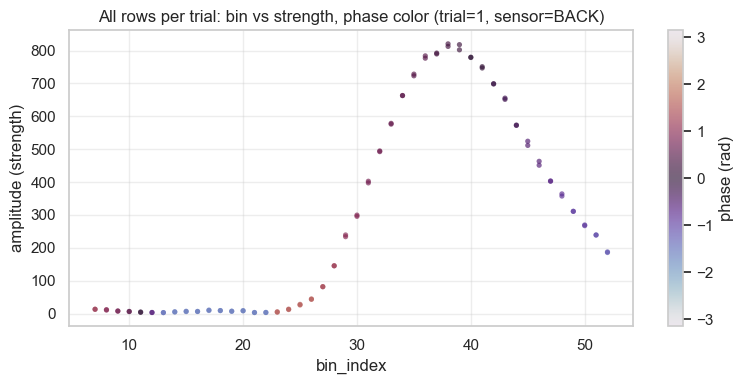

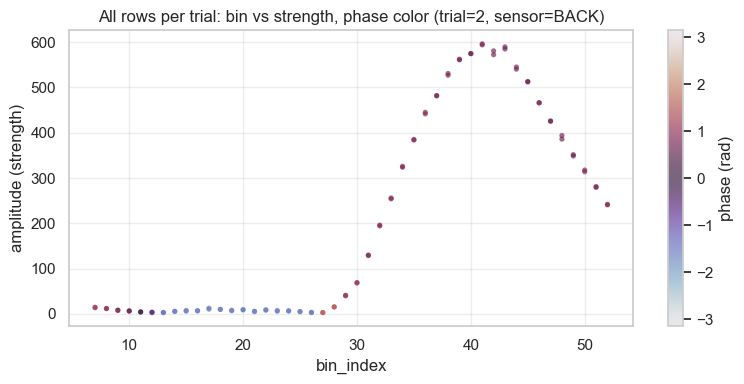

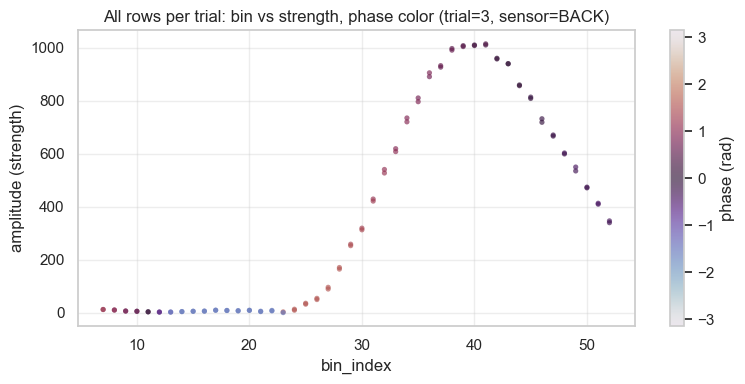

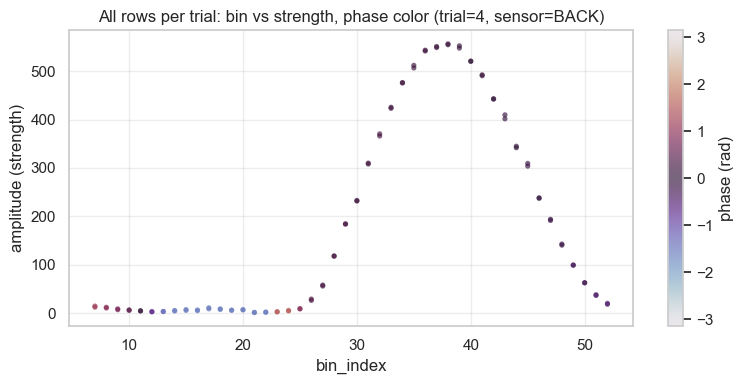

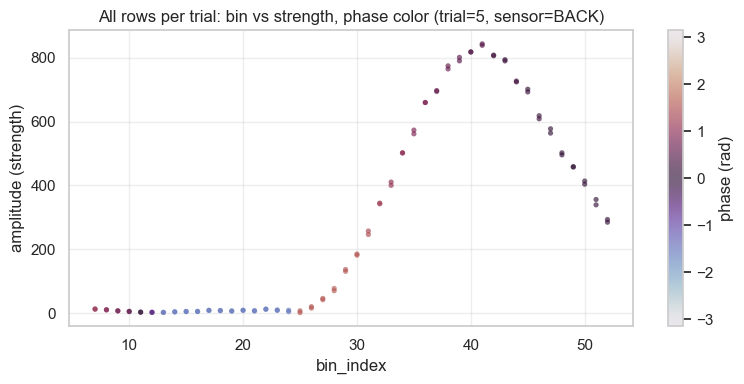

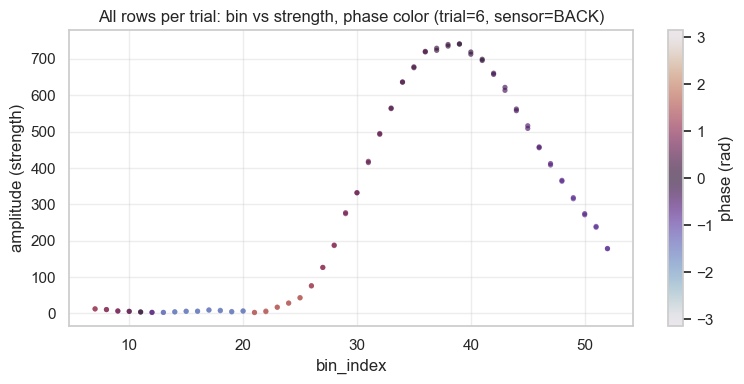

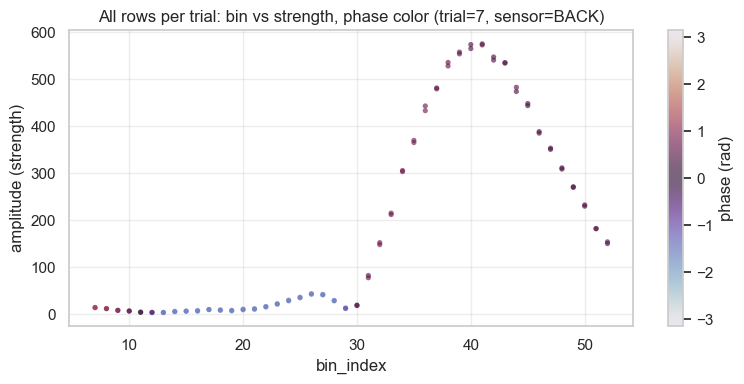

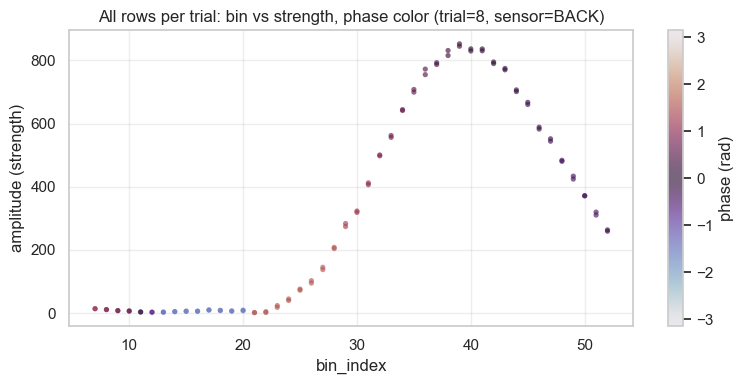

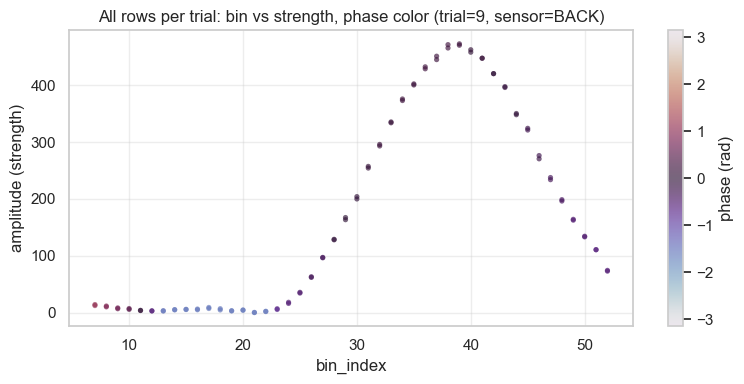

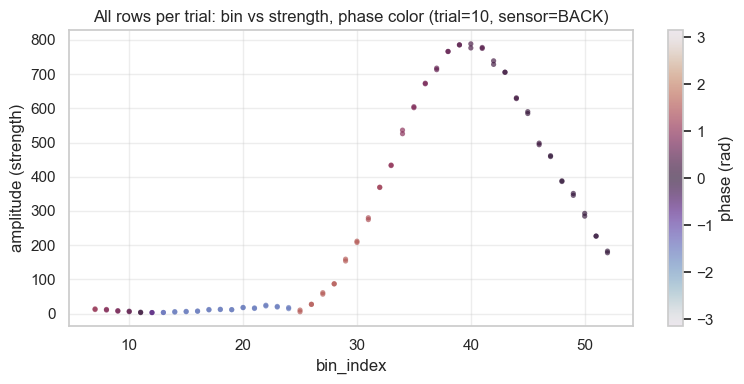

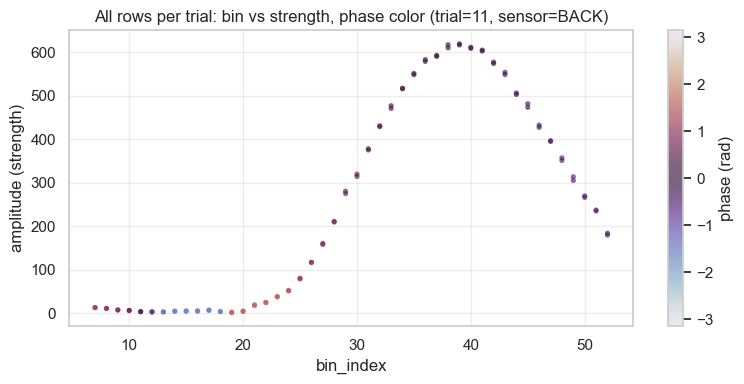

In [85]:
from matplotlib.colors import Normalize

_phase_norm = Normalize(vmin=-np.pi, vmax=np.pi)
_phase_s_min, _phase_s_max = 8.0, 100.0


def _phase_to_marker_sizes(phase: np.ndarray) -> np.ndarray:
    t = (np.asarray(phase, dtype=float) + np.pi) / (2.0 * np.pi)
    return _phase_s_min + t * (_phase_s_max - _phase_s_min)


for sensor in sorted(df["sensor"].unique()):
    sub_s = df[df["sensor"] == sensor]
    for trial in sorted(sub_s["trial"].unique().astype(int)):
        ss = sub_s[sub_s["trial"] == trial]
        ph = ss["phase_rad"].to_numpy(dtype=float)
        fig, ax = plt.subplots(figsize=(8, 4))
        if PHASE_AS_MARKER_SIZE:
            ax.scatter(
                ss["bin_index"],
                ss["amplitude"],
                s=_phase_to_marker_sizes(ph),
                c="#2563eb",
                alpha=0.55,
                edgecolors="white",
                linewidths=0.2,
            )
            mode = "phase → marker size (small≈−π, large≈+π)"
            ttl = (
                f"All rows per trial: bin vs strength, {mode} (trial={trial}, sensor={sensor})\n"
                f"(area linear in phase from −π to +π; marker {_phase_s_min:.0f}–{_phase_s_max:.0f} pt²)"
            )
        else:
            sc = ax.scatter(
                ss["bin_index"],
                ss["amplitude"],
                c=ss["phase_rad"],
                cmap="twilight",
                norm=_phase_norm,
                s=14,
                alpha=0.65,
                linewidths=0,
            )
            fig.colorbar(sc, ax=ax, label="phase (rad)")
            mode = "phase color (`twilight`)"
            ttl = f"All rows per trial: bin vs strength, {mode} (trial={trial}, sensor={sensor})"
        ax.set_xlabel("bin_index")
        ax.set_ylabel("amplitude (strength)")
        ax.set_title(ttl, fontsize=10)
        ax.grid(True, alpha=0.35)
        plt.tight_layout()
        plt.show()


## 5. Phase over time

`host_frame_id` / `t_ms` order: we use `frame_seq` (order of appearance per trial) as the primary
horizontal axis for phase vs frame. Use `np.unwrap` on sorted phase for continuity.


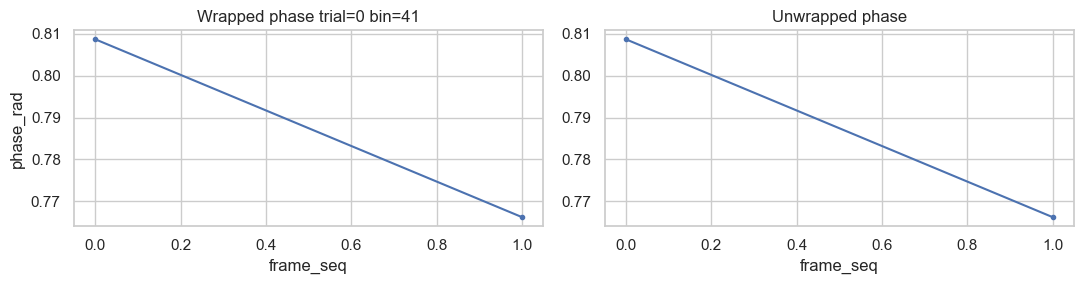

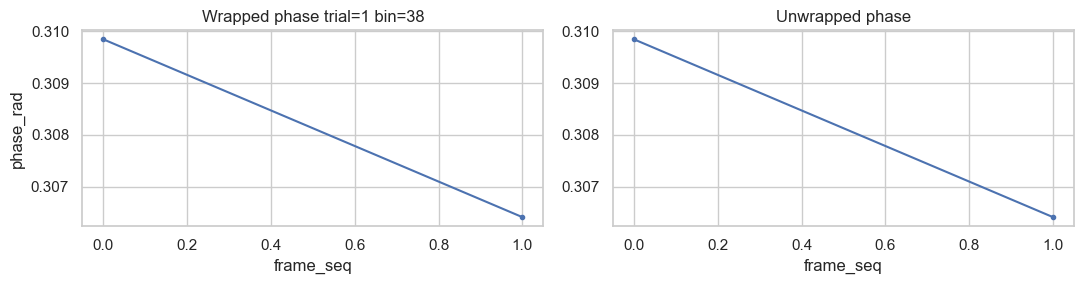

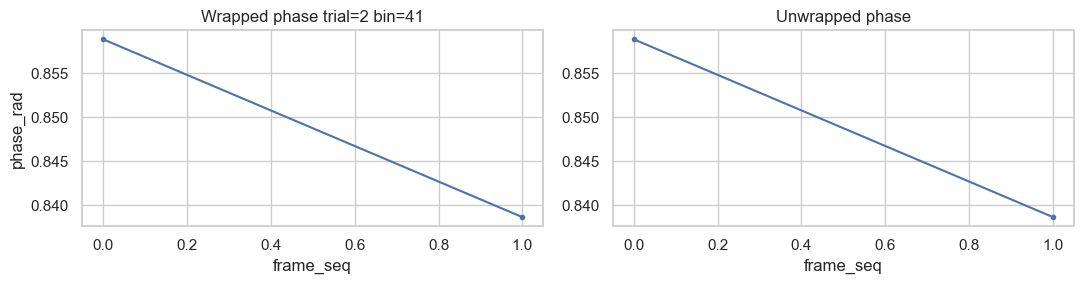

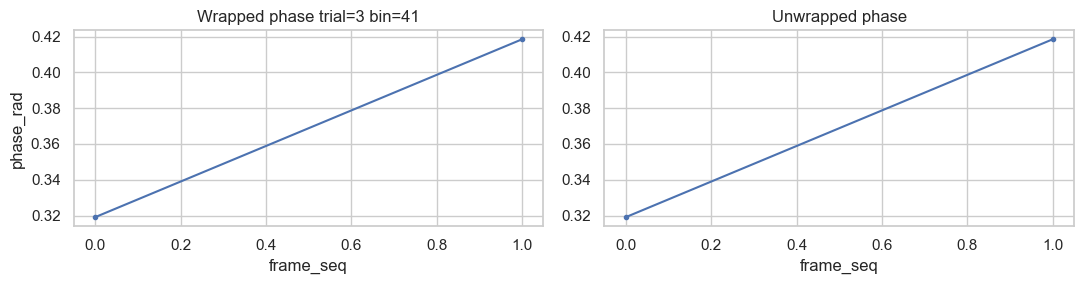

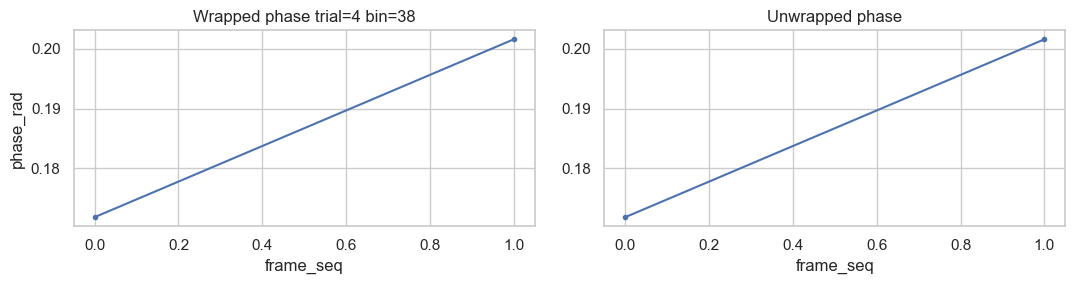

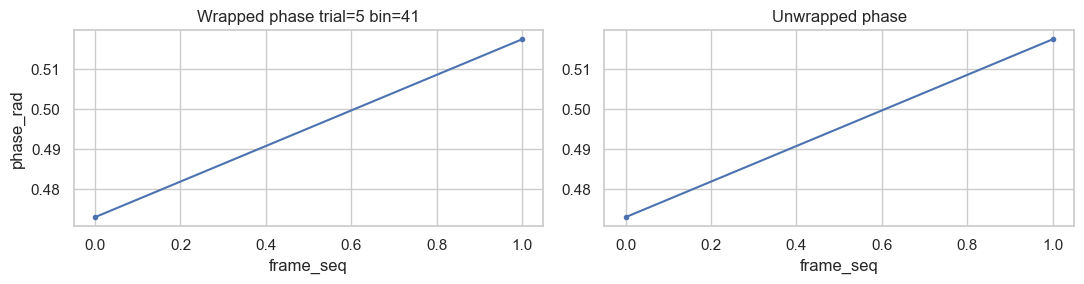

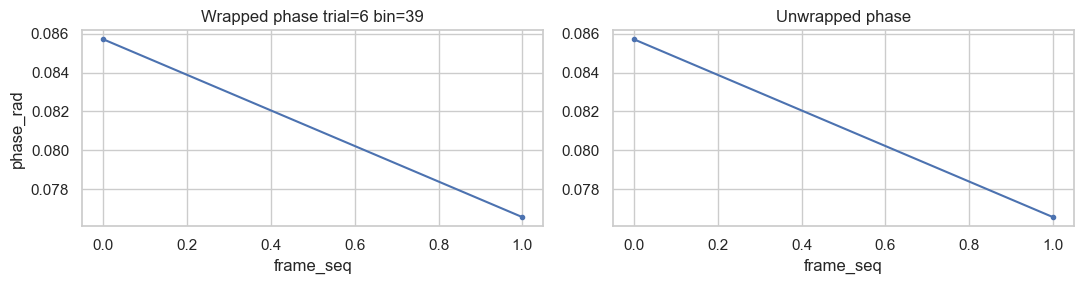

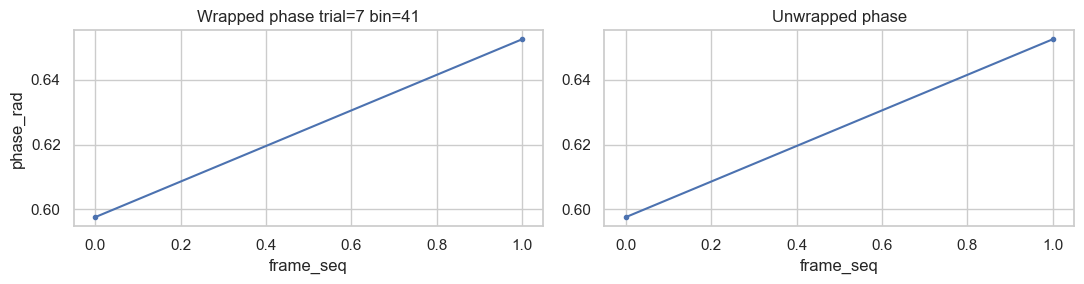

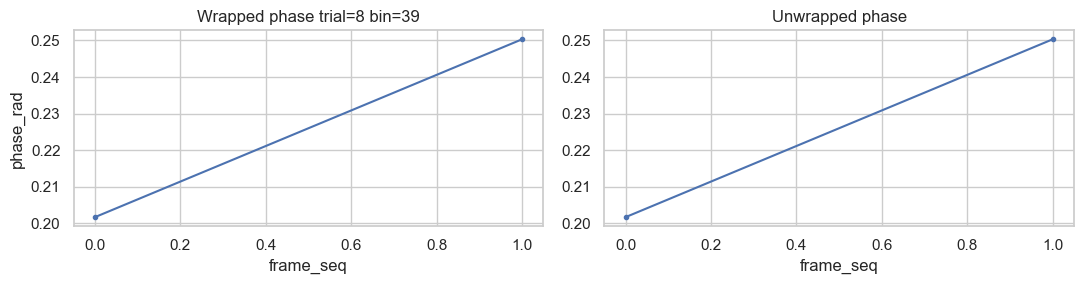

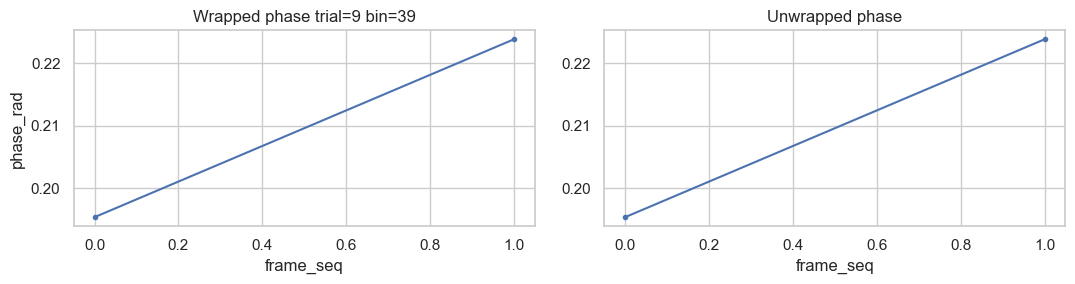

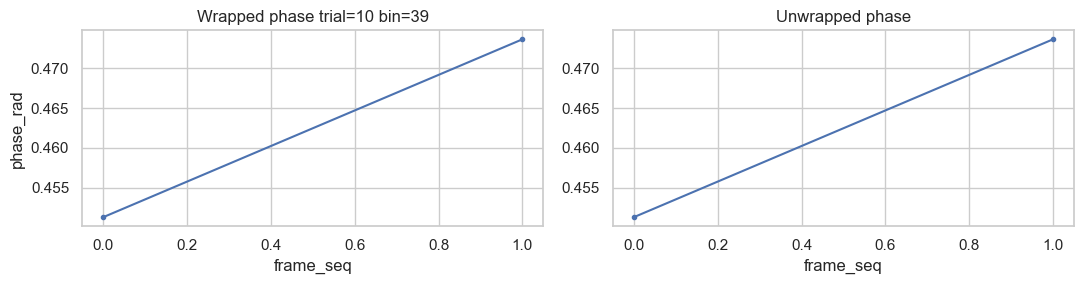

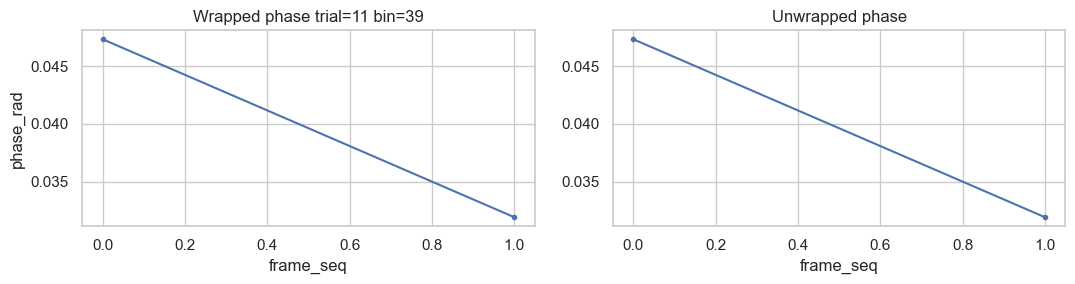

In [86]:
# Example: one bin (dominant by amplitude) per trial — wrapped and unwrapped phase vs frame_seq
for trial in sorted(df["trial"].unique()):
    sub = df[df["trial"] == trial]
    dom_bin = sub.groupby("bin_index")["amplitude"].mean().idxmax()
    ts = (
        sub.loc[sub["bin_index"] == dom_bin]
        .sort_values(["frame_seq", "bin_index"])
        .drop_duplicates("frame_key")
    )
    ph = ts["phase_rad"].values
    seq = ts["frame_seq"].values
    if len(ph) < 2:
        continue
    ph_u = np.unwrap(ph)
    fig, ax = plt.subplots(1, 2, figsize=(11, 3))
    ax[0].plot(seq, ph, ".-")
    ax[0].set_title(f"Wrapped phase trial={trial} bin={dom_bin}")
    ax[0].set_xlabel("frame_seq")
    ax[0].set_ylabel("phase_rad")
    ax[1].plot(seq, ph_u, ".-")
    ax[1].set_title("Unwrapped phase")
    ax[1].set_xlabel("frame_seq")
    plt.tight_layout()
    plt.show()


## 6. Strength centroid and peak localization (per trial)


 trial sensor  centroid_bin  peak_bin  fwhm_bins_est
     0   BACK     41.158669      41.0           17.0
     1   BACK     39.104874      38.0           14.0
     2   BACK     41.205678      41.0           16.0
     3   BACK     40.095831      41.0           17.0
     4   BACK     37.855261      38.0           14.0
     5   BACK     40.693320      41.0           15.0
     6   BACK     38.919895      39.0           16.0
     7   BACK     40.584256      41.0           14.0
     8   BACK     39.489819      39.0           17.0
     9   BACK     38.559936      39.0           15.0
    10   BACK     39.792650      39.0           14.0
    11   BACK     38.798290      39.0           19.0


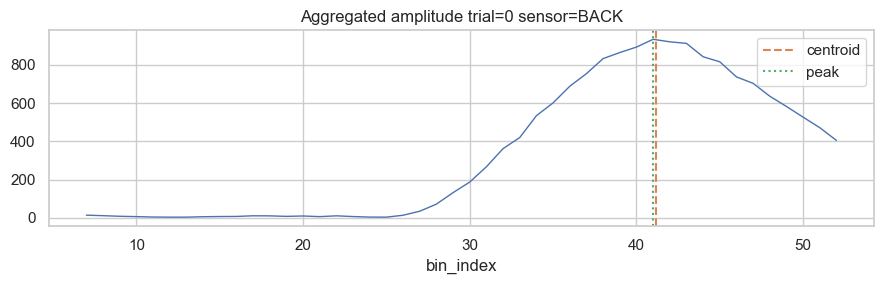

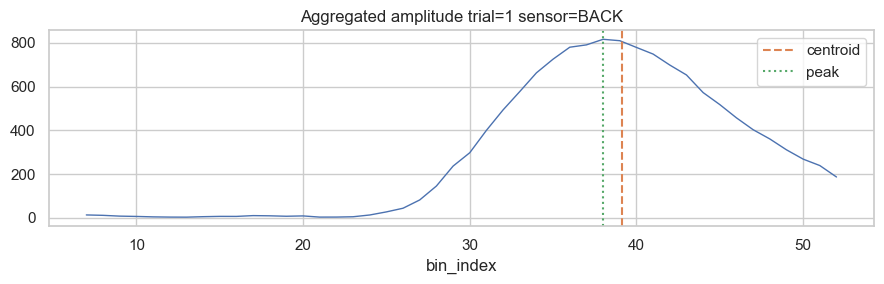

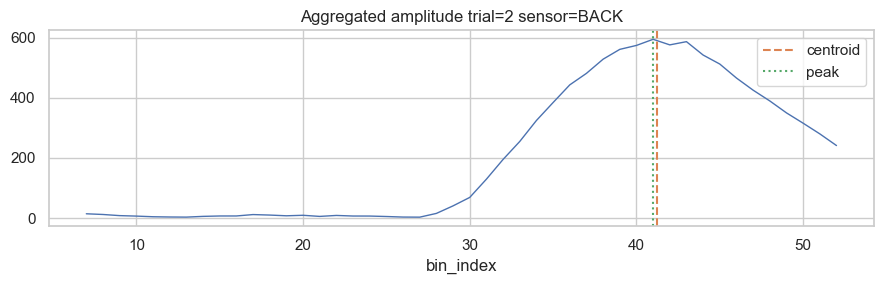

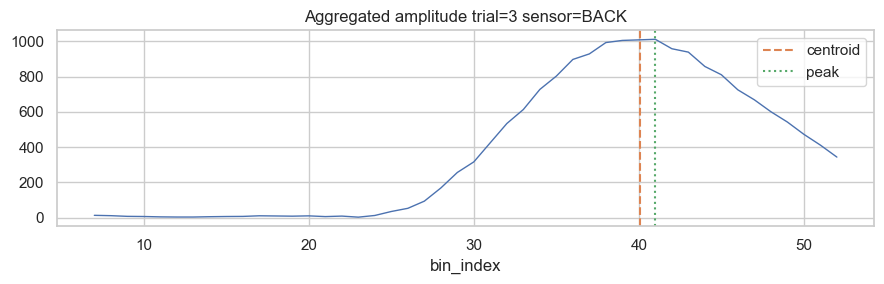

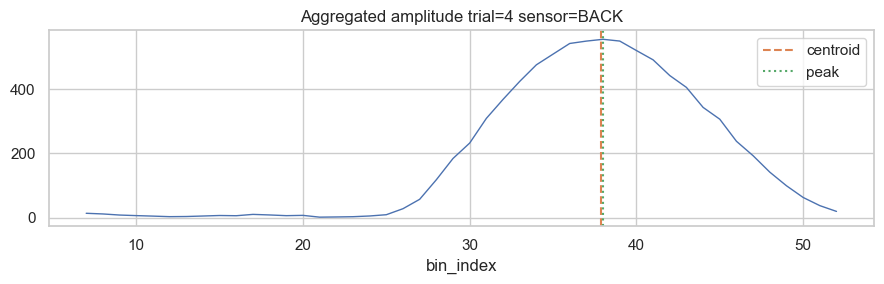

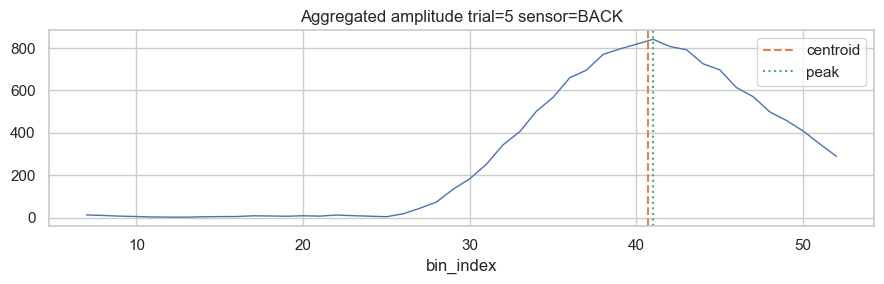

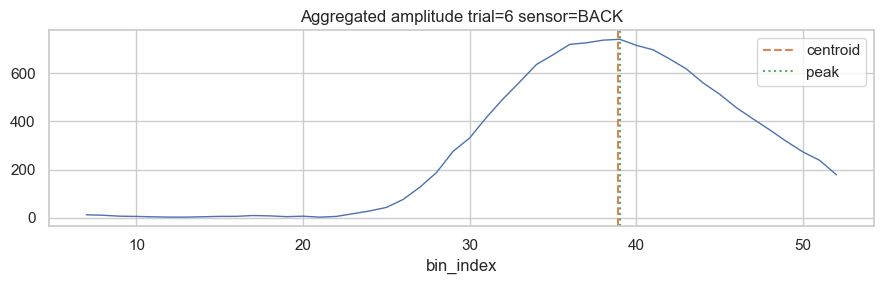

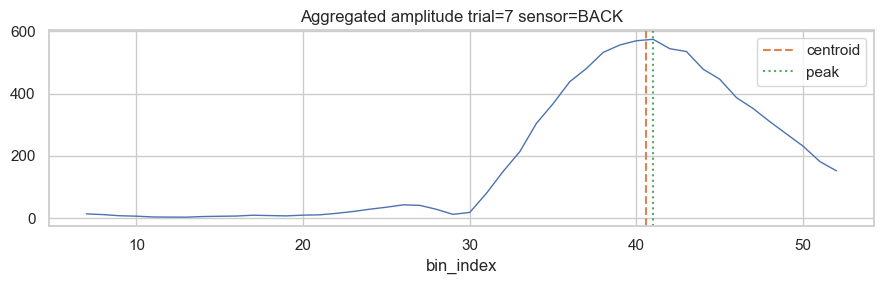

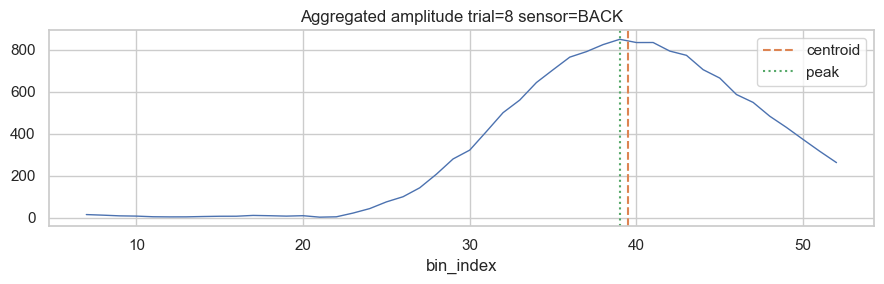

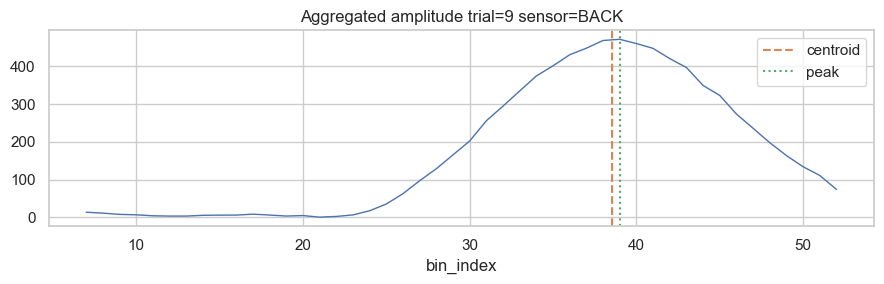

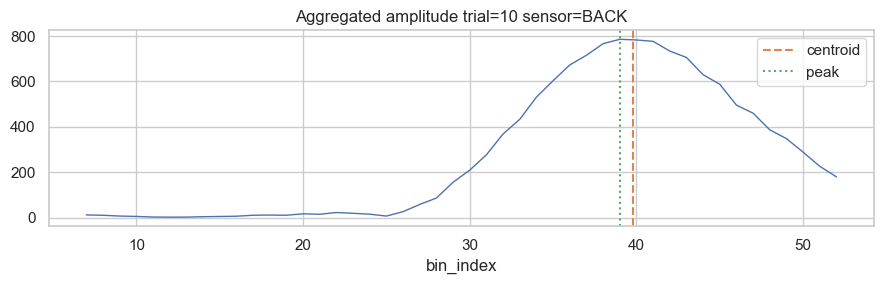

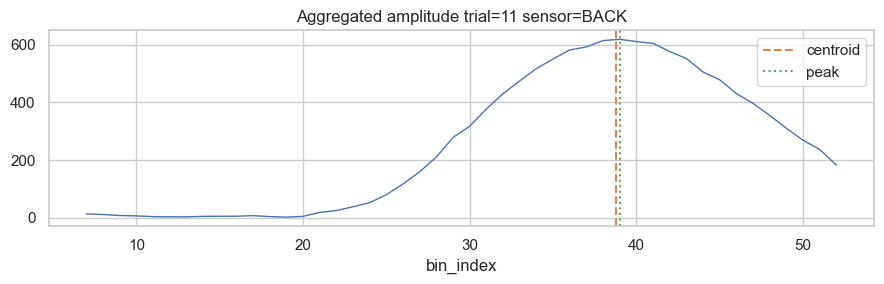

In [87]:
def fwhm_span(bin_indices: np.ndarray, weights: np.ndarray) -> tuple[float, float]:
    """Return (center_bin_approx, fwhm_bins) using half-max on discrete weights."""
    w = np.asarray(weights, dtype=float)
    b = np.asarray(bin_indices, dtype=float)
    if w.size == 0:
        return float("nan"), float("nan")
    peak_i = int(np.argmax(w))
    half = 0.5 * w[peak_i]
    left, right = peak_i, peak_i
    while left > 0 and w[left - 1] >= half:
        left -= 1
    while right < len(w) - 1 and w[right + 1] >= half:
        right += 1
    return float(b[peak_i]), float(b[right] - b[left] + 1e-9)


centroid_rows = []
for trial in sorted(df["trial"].unique()):
    for sensor in sorted(df.loc[df["trial"] == trial, "sensor"].unique()):
        sub = df[(df["trial"] == trial) & (df["sensor"] == sensor)]
        agg = sub.groupby("bin_index", observed=True)["amplitude"].agg(STRENGTH_AGG)
        b = agg.index.values
        w = agg.values.astype(float)
        if w.sum() <= 0:
            continue
        centroid = float(np.sum(b * w) / np.sum(w))
        peak_bin = float(b[np.argmax(w)])
        peak_h, span = fwhm_span(b, w)
        centroid_rows.append(
            {
                "trial": trial,
                "sensor": sensor,
                "centroid_bin": centroid,
                "peak_bin": peak_bin,
                "fwhm_bins_est": span,
            }
        )

cent_tbl = pd.DataFrame(centroid_rows)
print(cent_tbl.to_string(index=False))

for _, row in cent_tbl.iterrows():
    trial, sensor = int(row["trial"]), str(row["sensor"])
    sub = df[(df["trial"] == trial) & (df["sensor"] == sensor)]
    agg = sub.groupby("bin_index", observed=True)["amplitude"].agg(STRENGTH_AGG)
    plt.figure(figsize=(9, 3))
    plt.plot(agg.index, agg.values, lw=1)
    plt.axvline(row["centroid_bin"], color="C1", ls="--", label="centroid")
    plt.axvline(row["peak_bin"], color="C2", ls=":", label="peak")
    plt.title(f"Aggregated amplitude trial={trial} sensor={sensor}")
    plt.xlabel("bin_index")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 7. Phase vs trial (bins of interest)

**Bins of interest** per `(trial, sensor)` are the same candidate set as §2b (`candidate_bins_from_bumps`, or strongest bin fallback).

For each trial we report:
- **mean_bin_interest** — average of those bin indices  
- **median_bin_interest** — median of those bin indices (fractional if the middle falls between two bins)

**Phase** for that trial is evaluated **on the bin axis at `median_bin_interest`**: for each bin in the candidate set we take the **circular mean phase across all frames**, unwrap phase along sorted bins, then **linearly interpolate** to the median bin (no quantization of the median).

Plots: **x = trial**, **y = phase** (wrapped; second panel shows phase **unwrapped along trials** for slow trends). Optional `MM_PER_RAD`: trial-to-trial Δ of unwrapped phase mapped to indicative mm.


Bins of interest (mean / median) and bin count — before phase vs trial:
 trial sensor  mean_bin_interest  median_bin_interest  n_bins_interest
     0   BACK               41.5                 41.5                8
     1   BACK               38.5                 38.5                8
     2   BACK               41.5                 41.5                8
     3   BACK               40.5                 40.5                8
     4   BACK               37.5                 37.5                8
     5   BACK               40.5                 40.5                8
     6   BACK               38.5                 38.5                8
     7   BACK               40.5                 40.5                8
     8   BACK               39.5                 39.5                8
     9   BACK               38.5                 38.5                8
    10   BACK               39.5                 39.5                8
    11   BACK               39.5                 39.5                8


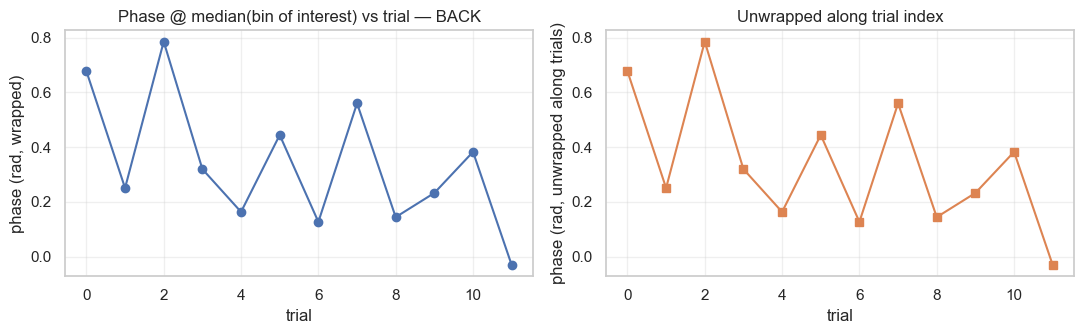

BACK: |Δφ| trial-to-trial (rad): count    11.000000
mean      0.334869
std       0.147633
min       0.088377
25%       0.218747
50%       0.413604
75%       0.429967
max       0.534892
MM_PER_RAD is None — set in config for indicative mm from trial-to-trial Δφ.


In [88]:
def phase_at_median_interest_bin(
    sub: pd.DataFrame,
    cand_list: list[float],
) -> tuple[float, float, float, int]:
    """Return (mean_bin, median_bin, phase_rad_wrapped_at_median, n_bins_with_data)."""
    cand = sorted({float(x) for x in cand_list})
    if not cand:
        return (float("nan"), float("nan"), float("nan"), 0)
    mean_bin = float(np.mean(cand))
    median_bin = float(np.median(cand))
    bins_phi: list[tuple[float, float]] = []
    bi = sub["bin_index"].astype(float)
    for bv in cand:
        m = np.isclose(bi, float(bv), rtol=0.0, atol=1e-5)
        sl = sub.loc[m]
        if sl.empty:
            continue
        z = np.exp(1j * sl["phase_rad"].to_numpy(dtype=float))
        bins_phi.append((float(bv), float(np.angle(z.mean()))))
    if not bins_phi:
        return mean_bin, median_bin, float("nan"), 0
    bins_phi.sort(key=lambda t: t[0])
    b_sorted = np.array([t[0] for t in bins_phi], dtype=float)
    p_sorted = np.array([t[1] for t in bins_phi], dtype=float)
    p_u = np.unwrap(p_sorted)
    if median_bin <= b_sorted[0]:
        ph = float(p_u[0])
    elif median_bin >= b_sorted[-1]:
        ph = float(p_u[-1])
    else:
        ph = float(np.interp(median_bin, b_sorted, p_u))
    ph_wrapped = float((ph + np.pi) % (2 * np.pi) - np.pi)
    return mean_bin, median_bin, ph_wrapped, len(bins_phi)


trial_phase_rows: list[dict] = []
for (trial, sensor), sub in df.groupby(["trial", "sensor"]):
    trial_i, sensor_s = int(trial), str(sensor)
    b, w = trial_sensor_profile(sub)
    bumps = detect_strength_bumps(b, w)
    cand_list = candidate_bins_from_bumps(bumps, b)
    if not cand_list and len(b) > 0:
        cand_list = [float(b[int(np.argmax(w))])]
    if not cand_list:
        continue
    mb, med_b, ph, nb = phase_at_median_interest_bin(sub, cand_list)
    trial_phase_rows.append(
        {
            "trial": trial_i,
            "sensor": sensor_s,
            "mean_bin_interest": mb,
            "median_bin_interest": med_b,
            "n_bins_interest": nb,
            "phase_rad": ph,
        }
    )

trial_phase_df = pd.DataFrame(trial_phase_rows)
if trial_phase_df.empty:
    print("No trial-level phase rows — check bump detection / data.")
else:
    print("Bins of interest (mean / median) and bin count — before phase vs trial:")
    show_cols = ["trial", "sensor", "mean_bin_interest", "median_bin_interest", "n_bins_interest"]
    print(trial_phase_df[show_cols].sort_values(["sensor", "trial"]).to_string(index=False))

    for sensor in sorted(trial_phase_df["sensor"].unique()):
        g = trial_phase_df[trial_phase_df["sensor"] == sensor].sort_values("trial")
        ph_w = g["phase_rad"].to_numpy(dtype=float)
        ph_u = np.unwrap(ph_w)
        fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
        axes[0].plot(g["trial"], ph_w, "o-", lw=1.5)
        axes[0].set_xlabel("trial")
        axes[0].set_ylabel("phase (rad, wrapped)")
        axes[0].set_title(f"Phase @ median(bin of interest) vs trial — {sensor}")
        axes[0].grid(True, alpha=0.3)
        axes[1].plot(g["trial"], ph_u, "s-", color="C1", lw=1.5)
        axes[1].set_xlabel("trial")
        axes[1].set_ylabel("phase (rad, unwrapped along trials)")
        axes[1].set_title("Unwrapped along trial index")
        axes[1].grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        dphi = np.diff(ph_u)
        if len(dphi):
            print(f"{sensor}: |Δφ| trial-to-trial (rad):", pd.Series(np.abs(dphi)).describe().round(6).to_string())
        if MM_PER_RAD is not None and len(dphi):
            trials_mid = (g["trial"].to_numpy()[1:] + g["trial"].to_numpy()[:-1]) / 2.0
            dd_mm = dphi * float(MM_PER_RAD)
            plt.figure(figsize=(8, 3))
            plt.plot(trials_mid, dd_mm * 1000.0, "o-", lw=1)
            plt.axhline(SUB_MM_THRESHOLD * 1000, color="C1", ls="--", label="5 mm ref")
            plt.xlabel("trial (midpoint between steps)")
            plt.ylabel("indicative Δmm × 1000")
            plt.title(f"Trial-to-trial Δ (MM_PER_RAD) — {sensor}")
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
        elif MM_PER_RAD is None and len(dphi):
            print("MM_PER_RAD is None — set in config for indicative mm from trial-to-trial Δφ.")


## Notes

- **Sub-5 mm:** Reliable detection needs a noise model on trial-to-trial `Δφ`; use a stationary
  trial range to estimate std, then set a threshold. `MM_PER_RAD` must come from geometry /
  calibration, not from this notebook alone.
- **Dual sensor:** `bin_index` is global across back+front when both stream; centroiding is per
  `(trial, sensor)` here.
